# Exploratory Data Analysis (EDA)

## Objective

Analyze hiring trends, salaries, locations, skills, companies, and career opportunities in the Indian technology job market.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("india_job_market_2024_2026.csv")

Query : Which tech roles have the most job opportunities?

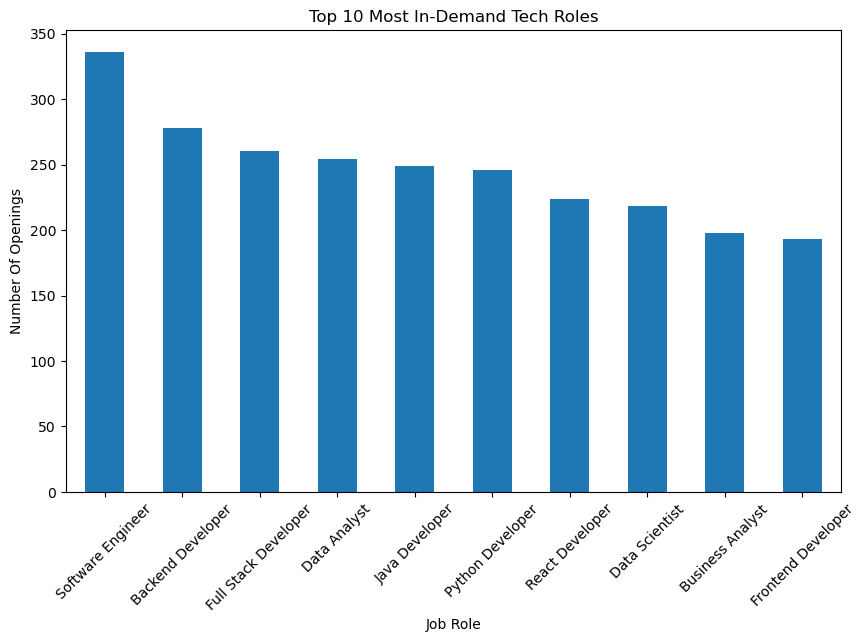

In [9]:
top_roles = df['Job_Title'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_roles.plot(kind='bar')
plt.title('Top 10 Most In-Demand Tech Roles')
plt.xlabel('Job Role')
plt.ylabel('Number Of Openings')
plt.xticks(rotation = 45)
plt.show()

### Observation:
Software Engineer has the highest number of job postings.

### Business Insight:
Software Engineering remains the most demanded role in the Indian tech market, indicating strong hiring demand across industries.

In [15]:
df.groupby('Job_Title')['Salary_LPA'].mean().sort_values(ascending=False).head(10)

Job_Title
Research Scientist           26.037500
AI Engineer                  24.858333
Data Scientist               24.258716
Computer Vision Engineer     23.257895
NLP Engineer                 22.419753
Engineering Manager          21.981176
Machine Learning Engineer    21.969231
MLOps Engineer               21.368182
Technical Lead               20.764964
UI/UX Designer               20.651200
Name: Salary_LPA, dtype: float64

In [16]:
df.groupby('Job_Title').agg({
    'Salary_LPA':'mean',
    'Openings':'sum'
}).sort_values('Openings', ascending=False).head(15)

,Salary_LPA,Openings
Job_Title,,
Software Engineer,18.846726,1253
Backend Developer,19.588129,1041
Full Stack Developer,18.764615,975
Data Analyst,20.588583,931
Java Developer,18.734940,911
Data Scientist,24.258716,879
Python Developer,19.341463,849
DevOps Engineer,20.511458,760
Frontend Developer,19.301554,753


In [17]:
df[df['Job_Title'] == 'Data Analyst']['Skills_Required'].head(20)

12     SQL, Tableau, Power BI, Statistics, Excel, Python
37     Tableau, Power BI, Excel, SQL, Python, Statistics
38       Data Visualization, Python, Tableau, Statistics
70     Data Visualization, Statistics, Power BI, Exce...
83     Power BI, SQL, Data Visualization, Tableau, Excel
95     Data Visualization, Tableau, Power BI, SQL, Excel
96     Python, Power BI, Excel, Data Visualization, S...
132        Tableau, Power BI, Data Visualization, Python
151                        Power BI, Statistics, Tableau
188    Data Visualization, SQL, Excel, Tableau, Power...
195      Excel, SQL, Tableau, Python, Data Visualization
235    Statistics, Excel, Data Visualization, Python,...
244                 Excel, Statistics, Power BI, Tableau
263                            Python, Tableau, Power BI
277    Statistics, Python, Data Visualization, Excel,...
326                         Power BI, Excel, Python, SQL
399    Statistics, SQL, Excel, Data Visualization, Po...
414    SQL, Data Visualization,

In [18]:
df[df['Job_Title'] == 'Data Scientist']['Skills_Required'].head(20)

133               NLP, Deep Learning, Pandas, Statistics
154    Statistics, Pandas, Tableau, Deep Learning, NL...
178    TensorFlow, Tableau, Deep Learning, Scikit-lea...
182    TensorFlow, Scikit-learn, NLP, Deep Learning, ...
185    NLP, TensorFlow, Machine Learning, Scikit-lear...
245     Tableau, Deep Learning, Scikit-learn, TensorFlow
300    Deep Learning, NLP, SQL, TensorFlow, Scikit-learn
381          TensorFlow, Deep Learning, Machine Learning
421                       NLP, Scikit-learn, SQL, Python
429              Tableau, Python, NLP, SQL, Scikit-learn
440    SQL, NLP, Machine Learning, Deep Learning, Pyt...
477             Tableau, Deep Learning, Machine Learning
504    Statistics, Scikit-learn, Machine Learning, De...
514    Scikit-learn, Deep Learning, Statistics, Pytho...
556         Tableau, Deep Learning, SQL, Statistics, NLP
568             Pandas, Statistics, Tableau, NLP, Python
597                Python, TensorFlow, SQL, Scikit-learn
636     Python, Statistics, Mac

In [19]:
data_analyst_skills = (
    df[df['Job_Title'] == 'Data Analyst']['Skills_Required']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

data_analyst_skills

Skills_Required
Data Visualization    178
Power BI              171
Statistics            169
SQL                   168
Tableau               160
Excel                 155
Python                143
Name: count, dtype: int64

In [20]:
data_scientist_skills = (
    df[df['Job_Title'] == 'Data Scientist']['Skills_Required']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

data_scientist_skills

Skills_Required
Statistics          121
NLP                 107
TensorFlow          101
Scikit-learn        101
Tableau              98
Machine Learning     96
Python               96
Pandas               92
SQL                  90
Deep Learning        88
Name: count, dtype: int64

In [21]:
df.groupby('City')['Salary_LPA'].mean().sort_values(ascending=False)

City
Kolkata        23.777895
Bhubaneswar    22.257426
Jaipur         21.093878
Pune           20.888679
Indore         20.793204
Chennai        20.583851
Bangalore      20.474128
Mumbai         20.030108
Remote         19.859488
Hyderabad      19.812256
Ahmedabad      18.546988
Lucknow        18.075510
Delhi          17.800000
Nagpur         17.683908
Kochi          17.569512
Chandigarh     17.206593
Coimbatore     16.315476
Name: Salary_LPA, dtype: float64

In [23]:
df.groupby('City').agg({
    'Salary_LPA':'mean',
    'Openings':'sum'
}).sort_values('Openings', ascending=False)

,Salary_LPA,Openings
City,,
Remote,19.859488,7009
Pune,20.888679,1490
Mumbai,20.030108,1366
Hyderabad,19.812256,1322
Delhi,17.800000,1222
Bangalore,20.474128,1220
Chennai,20.583851,1174
Lucknow,18.075510,436
Jaipur,21.093878,411


In [24]:
df.groupby('Experience_Level')['Salary_LPA'].mean().sort_values()

Experience_Level
Fresher (0-1 yr)      5.502544
Junior (1-3 yrs)      9.920382
Mid (3-6 yrs)        18.496734
Senior (6-10 yrs)    34.188448
Lead (10+ yrs)       52.952242
Name: Salary_LPA, dtype: float64

# Key Findings

## Finding 1
Python is the most demanded skill across the Indian tech job market.

## Finding 2
AI and Data Science roles offer the highest average salaries.

## Finding 3
Data Analyst roles focus on SQL, Excel, Power BI and Data Visualization, while Data Scientist roles require Machine Learning, TensorFlow, NLP and Scikit-learn.

## Finding 4
Data Scientist roles emphasize Python, Statistics, Machine Learning, TensorFlow, NLP, and Scikit-learn.

## Finding 5
Role demand and salary do not always move together. Software Engineer has the highest opportunities, while AI/Data Science roles have higher salaries.

## Finding 6 
Average salary increases significantly with experience, rising from 5.5 LPA for freshers to nearly 53 LPA for lead-level professionals.

## Finding 7
Salary growth accelerates at senior levels, indicating that experience and leadership responsibilities contribute heavily to compensation growth.